# Unidade I — Mineração de Dados

## Introdução à mineração de dados

**Carga estimada:** 3 horas  
**Pré-requisitos:** Python básico e noções de Inteligência Artificial.

> **Pergunta norteadora:** que tipo de conhecimento pode ser extraído de dados e como reconhecer a tarefa de mineração adequada?


## Objetivos de aprendizagem

Ao concluir este notebook, você será capaz de:

- distinguir dados, informação, padrão e conhecimento;
- caracterizar mineração de dados no contexto da descoberta de conhecimento;
- diferenciar tarefas descritivas e preditivas;
- associar perguntas de aplicação a classificação, regressão, agrupamento, associação ou detecção de anomalias;
- reconhecer riscos de privacidade, viés e interpretações indevidas.


## De dados a conhecimento

Um **dado** é uma representação registrada de uma observação. Quando recebe contexto e significado, ele fornece **informação**. Um **padrão** descreve uma regularidade ou estrutura recorrente. O padrão se torna **conhecimento útil** quando é válido, compreensível, relevante para uma decisão e interpretado dentro de suas limitações.

Mineração de dados é o conjunto de métodos usados para descobrir padrões interessantes em coleções de dados. Ela não é sinônimo de todo o processo: escolher o problema, obter e preparar dados, avaliar resultados e comunicar conclusões também são etapas essenciais.

> **Exemplo:** uma tabela de compras contém dados. A taxa de recompra por categoria é informação. A coocorrência persistente entre dois produtos é um padrão. Uma política de recomendação testada, útil e monitorada representa uso do conhecimento.


## Tarefas de mineração

| Tarefa | Pergunta típica | Tipo de saída | Exemplo |
|---|---|---|---|
| Classificação | A qual classe pertence? | Rótulo discreto | Mensagem é spam ou não? |
| Regressão | Qual valor numérico esperar? | Valor contínuo | Qual será a demanda? |
| Agrupamento | Que grupos naturais existem? | Partição ou estrutura de grupos | Quais perfis de consumo aparecem? |
| Associação | Que itens/eventos ocorrem juntos? | Regras e itemsets | Quais produtos são comprados juntos? |
| Detecção de outliers | O que foge ao comportamento esperado? | Escore ou alerta | Qual transação merece investigação? |

Classificação e regressão são tipicamente **preditivas**: aprendem uma relação para estimar um alvo conhecido. Agrupamento e associação são tipicamente **descritivos**: procuram estrutura sem um alvo previamente definido. Detecção de outliers pode ser supervisionada ou não supervisionada.


### Como reconhecer visualmente cada tarefa

A figura enfatiza o **tipo de saída** produzido por cada tarefa. Os desenhos são representações conceituais: não correspondem a resultados de algoritmos executados nem sugerem que dados reais sempre apresentem separações tão nítidas.

![Cinco painéis conceituais: classificação separa pontos em classes; regressão ajusta uma curva para produzir valores numéricos; agrupamento identifica grupos sem rótulos prévios; associação relaciona itens que ocorrem juntos; e detecção de outliers destaca uma observação isolada.](../../imagens/unidades/unidade_01/tarefas_mineracao.svg)

*Figura — Representações conceituais das principais tarefas de mineração. Elaboração própria.*

Observe que classificação e agrupamento podem parecer semelhantes depois de representados por cores. A diferença está na pergunta e na informação disponível: na classificação, as classes conhecidas orientam a aprendizagem; no agrupamento, os grupos são procurados sem esses rótulos prévios. Um outlier, por sua vez, é apenas uma observação incomum segundo algum critério — não necessariamente um erro ou uma fraude.


## Primeira exploração de dados

O conjunto Iris contém medidas de sépalas e pétalas de 150 flores, distribuídas em três espécies. Nesta etapa não construiremos um modelo: vamos reconhecer objetos, atributos e possíveis tarefas.


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="notebook")

iris = load_iris(as_frame=True)
dados = iris.frame.rename(columns={"target": "especie_codigo"})
dados["especie"] = dados["especie_codigo"].map(dict(enumerate(iris.target_names)))
dados.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),especie_codigo,especie
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [2]:
resumo = dados.groupby("especie", observed=True)[
    ["petal length (cm)", "petal width (cm)"]
].mean().round(2)
resumo


,petal length (cm),petal width (cm)
especie,,
setosa,1.46,0.25
versicolor,4.26,1.33
virginica,5.55,2.03


A tabela resume um padrão: as médias das dimensões das pétalas diferem entre espécies. Isso sugere que esses atributos podem ajudar a prever a espécie, mas médias diferentes não garantem separação perfeita entre todas as flores. Precisamos observar a distribuição conjunta.


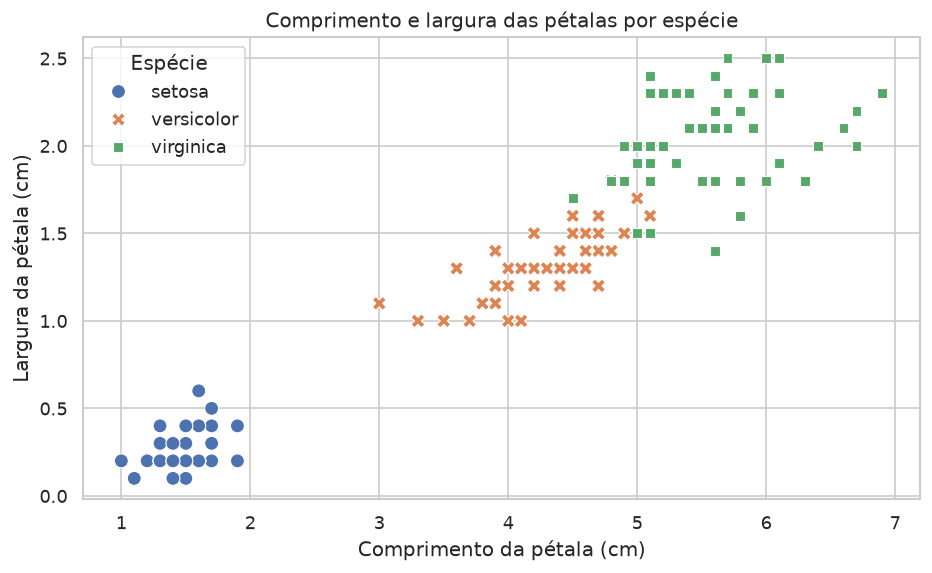

In [3]:
fig, ax = plt.subplots(figsize=(9, 5), dpi=120)
sns.scatterplot(
    data=dados, x="petal length (cm)", y="petal width (cm)",
    hue="especie", style="especie", s=70, ax=ax,
)
ax.set(
    title="Comprimento e largura das pétalas por espécie",
    xlabel="Comprimento da pétala (cm)",
    ylabel="Largura da pétala (cm)",
)
ax.legend(title="Espécie")
plt.show()


A espécie *setosa* aparece visualmente separada, enquanto *versicolor* e *virginica* apresentam alguma sobreposição. Se a espécie for conhecida durante o treinamento, temos um problema de classificação. Se ocultarmos os rótulos e perguntarmos quais grupos existem, temos um problema de agrupamento — e os grupos encontrados não precisam coincidir exatamente com as espécies.

## Da pergunta à tarefa

Uma tarefa não é determinada apenas pelo conjunto de dados. Ela depende da pergunta, da informação disponível no momento da decisão e da forma de saída necessária. A mesma tabela pode sustentar classificação da espécie, regressão do comprimento da pétala, agrupamento de flores ou detecção de medidas atípicas.

> **U01-NB01-V01 — Verifique seu entendimento:** prever se um estudante será aprovado é classificação ou regressão? E prever sua nota final? Justifique pela saída esperada.

> **U01-NB01-E01 — Exercício:** para cada cenário abaixo, indique tarefa, entrada, saída e uma métrica ou critério de sucesso: (a) estimar consumo mensal de energia; (b) descobrir combinações frequentes de disciplinas; (c) encontrar sensores com comportamento incomum; (d) segmentar municípios sem rótulos prévios.


## Mineração de dados e sociedade

Um padrão matematicamente forte pode ser inútil, injusto ou fruto de coleta inadequada. Antes de usar um resultado, pergunte:

- os dados representam a população e o período de interesse?
- há atributos sensíveis ou substitutos indiretos desses atributos?
- quem suporta o custo de falsos positivos e falsos negativos?
- existe autorização e finalidade legítima para o uso?
- o resultado será monitorado após a implantação?

Essas perguntas não são uma etapa opcional posterior: fazem parte da formulação e da avaliação do problema.


## Síntese

- Mineração de dados descobre padrões; conhecimento exige contexto, validade e utilidade.
- A pergunta e o tipo de saída determinam a tarefa de mineração.
- Tarefas preditivas usam um alvo; tarefas descritivas buscam estrutura.
- Qualidade, privacidade, viés e impacto devem acompanhar todo o processo.

## Referências

- HAN, Jiawei; PEI, Jian; TONG, Hanghang. *Data Mining: Concepts and Techniques*. 4. ed. Cambridge: Morgan Kaufmann/Elsevier, 2023. Cap. 1, seções 1.1–1.7.
- FISHER, R. A. The use of multiple measurements in taxonomic problems. *Annals of Eugenics*, v. 7, n. 2, p. 179–188, 1936. Conjunto Iris distribuído pelo scikit-learn.
